# Model Evaluation

This notebook evaluates the performance of the trained machine learning models using multiple classification metrics and visualizations. The objective is to compare different machine learning models and identify the best-performing model for customer churn prediction.

In [1]:
# Libraries

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# Dataset

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
# Models

log_model = joblib.load("../models/logistic_regression.pkl")
tree_model = joblib.load("../models/decision_tree.pkl")
forest_model = joblib.load("../models/random_forest.pkl")

In [4]:
# Logistic Regression
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

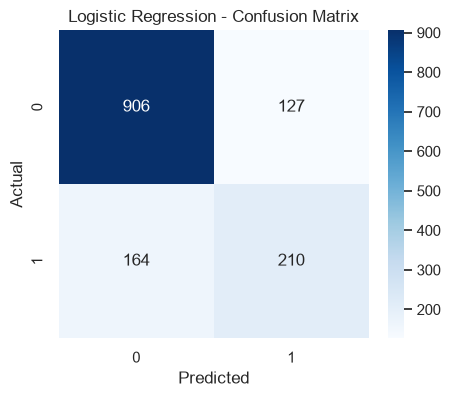

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [6]:
# Classification Report
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1033
           1       0.62      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



In [7]:
# Decision Tree
tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

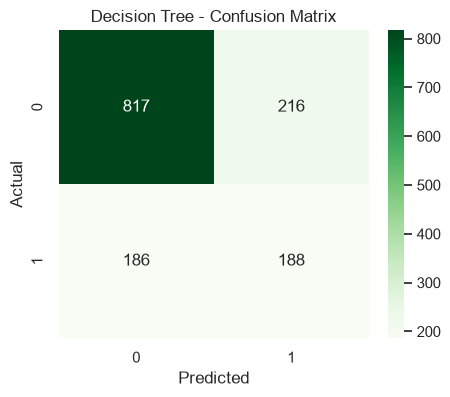

In [8]:
cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1033
           1       0.47      0.50      0.48       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.72      1407



In [10]:
# Random Forest
forest_pred = forest_model.predict(X_test)
forest_prob = forest_model.predict_proba(X_test)[:, 1]

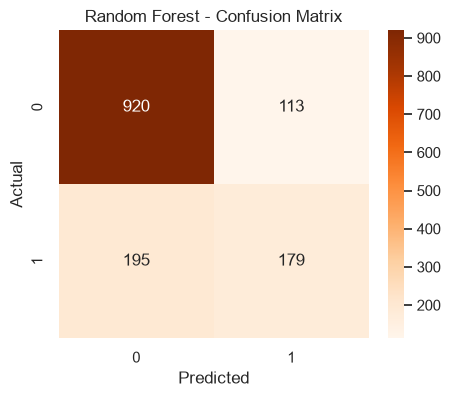

In [11]:
cm = confusion_matrix(y_test, forest_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
print(classification_report(y_test, forest_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



<Figure size 800x600 with 0 Axes>

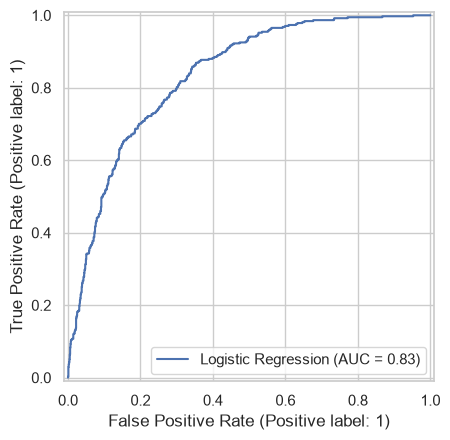

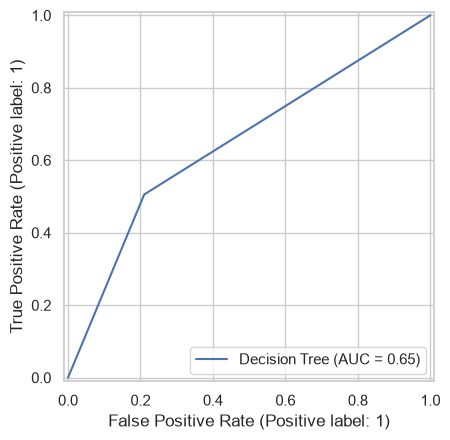

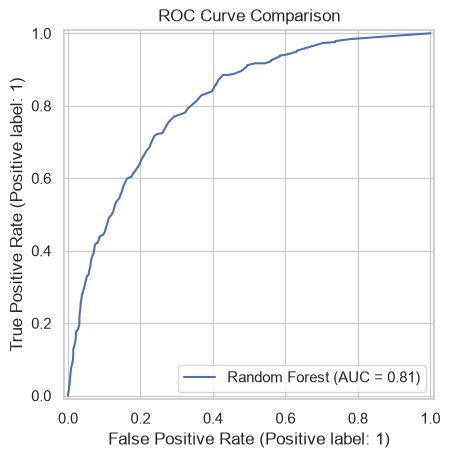

In [13]:
# ROC Curve Comparison
plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    tree_prob,
    name="Decision Tree"
)

RocCurveDisplay.from_predictions(
    y_test,
    forest_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")

plt.show()

In [14]:
# Performance comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, forest_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, forest_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, forest_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, forest_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, tree_prob),
        roc_auc_score(y_test, forest_prob)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.793,0.623,0.561,0.591,0.835
1,Decision Tree,0.714,0.465,0.503,0.483,0.648
2,Random Forest,0.781,0.613,0.479,0.538,0.811


In [15]:
# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

C:\Users\harsh\AppData\Local\Temp\ipykernel_19904\3793367439.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


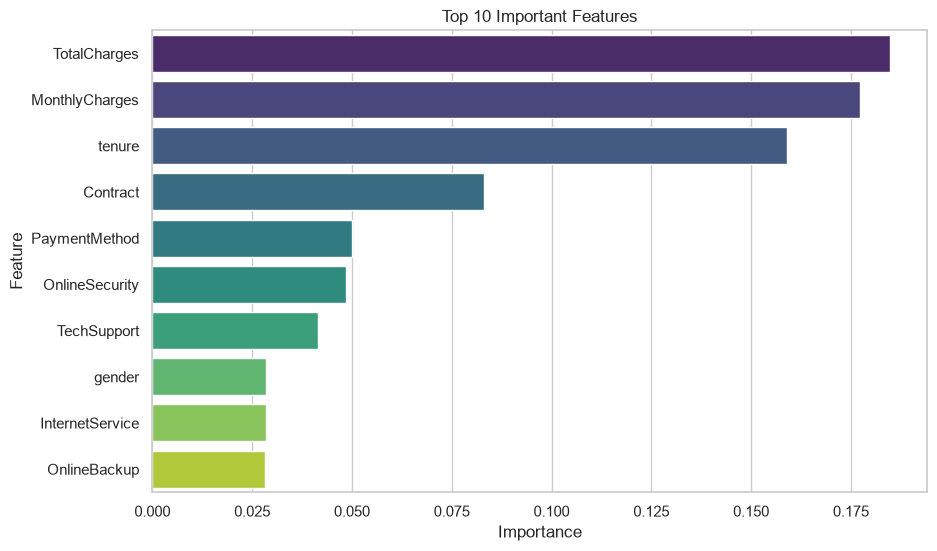

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")

plt.show()

# Conclusion

Among the evaluated models, Random Forest achieved the strongest overall performance based on ROC-AUC, precision, recall, and F1-score. Therefore, it will be selected as the final model for deployment in the Streamlit dashboard.